# Homelessness Queue Study: Impact of Classification Accuracy

This study models a housing queue with two types of individuals:

- **Chronic homeless**
- **Transient homeless**

The objective of the system is to prioritize chronic individuals, since they face greater long-term harm from abandonment.

However, the system cannot directly observe true type. Instead, it relies on a classification tool that predicts whether an individual is chronic or transient. 

The classification tool has imperfect accuracy.

The study investigates how the accuracy of this classification tool affects outcomes, particularly the probability that a truly chronic individual abandons the queue.

The system operates under heavy congestion, which reflects real-world housing shortages.

We vary:

- classifier accuracy
- system congestion (arrival load)

and measure:

$$
P(\text{abandon} \mid \text{true chronic})
$$

along with other queue performance metrics.

The main question is:

> How much does improving classification accuracy reduce abandonment among the truly chronic population?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gi_gi_n_gi_multiclass.core.engine_multi import run_sim_multi
from gi_gi_n_gi_multiclass.core.types_multi import CustomerClass, MultiSimConfig
from gi_gi_n_gi_multiclass.dists.common import Exponential
from gi_gi_n_gi_multiclass.policies.priority_fcfs import PriorityFCFS
from gi_gi_n_gi_multiclass.labelling import ConfusionMatrixClassifier
from gi_gi_n_gi_multiclass.metrics.class_metrics import (
    abandonment_probability_by_true_class,
    abandonment_probability_by_assigned_class,
)
from gi_gi_n_gi_multiclass.outputs.tables import class_level_summary

## Study parameters

We define:

- number of servers (housing placements)
- service rate
- chronic arrival rate
- a grid of transient arrival rates to create different congestion levels
- a grid of classifier accuracy values
- simulation seeds for Monte Carlo averaging

System load is measured as

$$
\rho = \frac{\lambda_c + \lambda_t}{N\mu}
$$

where

- $\lambda_c$ = chronic arrival rate  
- $\lambda_t$ = transient arrival rate  
- $N$ = number of servers  
- $\mu$ = service rate.

In [7]:
N = 10
mu = 1.0

lambda_chronic = 8.0
lambda_transient_grid = [6.0, 8.0, 10.0, 12.0]

accuracy_grid = np.linspace(0.50, 1.00, 11)
seeds = [1, 2, 3, 4, 5]

warmup_time = 500.0
run_time = 1000.0

policy = PriorityFCFS(priority_order=[0, 1])   # prioritize assigned chronic

## Classifier model

The classification tool is modeled with a symmetric confusion matrix:

$$
\begin{bmatrix}
a & 1-a \\
1-a & a
\end{bmatrix}
$$

where

- $a$ is the classifier accuracy
- rows represent true class
- columns represent assigned class.

When $a=1$ the classifier is perfect.

When $a=0.5$ the classifier is completely uninformative.

In [8]:
def symmetric_classifier(accuracy: float) -> ConfusionMatrixClassifier:
    return ConfusionMatrixClassifier(
        np.array([
            [accuracy, 1.0 - accuracy],
            [1.0 - accuracy, accuracy],
        ])
    )

## Single simulation scenario

This helper function runs one simulation for a given:

- transient arrival rate
- classifier accuracy
- random seed.

It constructs the two customer classes, applies the classifier, runs the queue simulation, and extracts the key outcome metrics.

In [9]:
def run_one_scenario(lambda_transient: float, accuracy: float, seed: int) -> dict:
    class_chronic = CustomerClass(
        name="chronic",
        interarrival=Exponential(rate=lambda_chronic),
        service=Exponential(rate=mu),
        patience=Exponential(rate=0.5),
    )

    class_transient = CustomerClass(
        name="transient",
        interarrival=Exponential(rate=lambda_transient),
        service=Exponential(rate=mu),
        patience=Exponential(rate=0.5),
    )

    classes = [class_chronic, class_transient]

    cfg = MultiSimConfig(
        n_servers=N,
        classes=classes,
        classifier=symmetric_classifier(accuracy),
        policy=policy,
        seed=seed,
        warmup_time=warmup_time,
        run_time=run_time,
        collect_event_log=False,
    )

    res = run_sim_multi(cfg)
    summ = class_level_summary(res)
    overall = summ[summ["scope"] == "OVERALL"].iloc[0]

    return {
        "lambda_transient": lambda_transient,
        "accuracy": accuracy,
        "seed": seed,
        "rho": (lambda_chronic + lambda_transient) / (N * mu),
        "true_chronic_abandon_prob": abandonment_probability_by_true_class(res, 0),
        "true_transient_abandon_prob": abandonment_probability_by_true_class(res, 1),
        "assigned_chronic_abandon_prob": abandonment_probability_by_assigned_class(res, 0),
        "assigned_transient_abandon_prob": abandonment_probability_by_assigned_class(res, 1),
        "served_rate": overall["served_rate"],
        "abandon_rate": overall["abandon_rate"],
        "L_timeavg": overall["L_timeavg"],
        "Lq_timeavg": overall["Lq_timeavg"],
    }

## Full experiment grid

We run simulations over the full grid of:

- transient arrival rates
- classifier accuracy levels
- Monte Carlo seeds.

All results are stored in a single dataframe.

In [10]:
rows = []

for lambda_transient in lambda_transient_grid:
    for accuracy in accuracy_grid:
        for seed in seeds:
            rows.append(run_one_scenario(lambda_transient, accuracy, seed))

results = pd.DataFrame(rows)
results.head()

,lambda_transient,accuracy,seed,rho,true_chronic_abandon_prob,true_transient_abandon_prob,assigned_chronic_abandon_prob,assigned_transient_abandon_prob,served_rate,abandon_rate,L_timeavg,Lq_timeavg
0,6.0,0.5,1,1.4,0.287394,0.297184,0.101343,0.478891,9.867,4.071,18.006883,8.088490
1,6.0,0.5,2,1.4,0.300237,0.292213,0.105456,0.492155,9.855,4.167,18.423967,8.489560
2,6.0,0.5,3,1.4,0.293225,0.288578,0.101242,0.483992,9.845,4.050,18.124681,8.217523
3,6.0,0.5,4,1.4,0.290242,0.290748,0.100593,0.476744,9.893,4.058,18.276218,8.348838
4,6.0,0.5,5,1.4,0.292142,0.286984,0.095916,0.483040,9.871,4.042,18.057508,8.120245


## Aggregating results

Simulation results are averaged across random seeds to estimate:

- chronic abandonment probability
- transient abandonment probability
- service rate
- abandonment rate
- queue length metrics.

In [11]:
summary = (
    results.groupby(["lambda_transient", "accuracy"])[[
        "rho",
        "true_chronic_abandon_prob",
        "true_transient_abandon_prob",
        "served_rate",
        "abandon_rate",
        "L_timeavg",
        "Lq_timeavg",
    ]]
    .agg(["mean", "std"])
)

summary

rho      true_chronic_abandon_prob            \
                          mean  std                      mean       std   
lambda_transient accuracy                                                 
6.0              0.50      1.4  0.0                  0.292648  0.004785   
                 0.55      1.4  0.0                  0.276778  0.002844   
                 0.60      1.4  0.0                  0.258351  0.004121   
                 0.65      1.4  0.0                  0.241152  0.004090   
                 0.70      1.4  0.0                  0.225330  0.003091   
                 0.75      1.4  0.0                  0.207858  0.004912   
                 0.80      1.4  0.0                  0.190882  0.004799   
                 0.85      1.4  0.0                  0.172260  0.002475   
                 0.90      1.4  0.0                  0.154332  0.003870   
                 0.95      1.4  0.0                  0.137637  0.004507   
                 1.00      1.4  0.0                  0.117608  0.003097   
8.0              0.50      1.6  0.0                  0.377017  0.006709   
                 0.55      1.6  0.0                  0.350360  0.005558   
                 0.60      1.6  0.0                  0.324576  0.005144   
                 0.65      1.6  0.0                  0.298289  0.005763   
                 0.70      1.6  0.0                  0.272879  0.004201   
                 0.75      1.6  0.0                  0.248123  0.004881   
                 0.80      1.6  0.0                  0.223310  0.003485   
                 0.85      1.6  0.0                  0.196573  0.002522   
                 0.90      1.6  0.0                  0.173484  0.003413   
                 0.95      1.6  0.0                  0.148602  0.003509   
                 1.00      1.6  0.0                  0.121463  0.004202   
10.0             0.50      1.8  0.0                  0.446654  0.006952   
                 0.55      1.8  0.0                  0.411656  0.009635   
                 0.60      1.8  0.0                  0.376135  0.004972   
                 0.65      1.8  0.0                  0.343992  0.003969   
                 0.70      1.8  0.0                  0.311926  0.003423   
                 0.75      1.8  0.0                  0.279407  0.002671   
                 0.80      1.8  0.0                  0.248113  0.002624   
                 0.85      1.8  0.0                  0.214614  0.003819   
                 0.90      1.8  0.0                  0.183148  0.004184   
                 0.95      1.8  0.0                  0.152907  0.004658   
                 1.00      1.8  0.0                  0.121118  0.003789   
12.0             0.50      2.0  0.0                  0.506521  0.003590   
                 0.55      2.0  0.0                  0.466519  0.003722   
                 0.60      2.0  0.0                  0.424258  0.003667   
                 0.65      2.0  0.0                  0.384081  0.003060   
                 0.70      2.0  0.0                  0.347277  0.002917   
                 0.75      2.0  0.0                  0.306645  0.004303   
                 0.80      2.0  0.0                  0.266290  0.003065   
                 0.85      2.0  0.0                  0.229393  0.003967   
                 0.90      2.0  0.0                  0.194245  0.004401   
                 0.95      2.0  0.0                  0.156116  0.002758   
                 1.00      2.0  0.0                  0.121241  0.003114   

                          true_transient_abandon_prob           served_rate  \
                                                 mean       std        mean   
lambda_transient accuracy                                                     
6.0              0.50                        0.291142  0.003926      9.8662   
                 0.55                        0.312971  0.003453      9.8634   
                 0.60                        0.334146  0.005998      9.8842   
                 0.65      

## Plotting dataset

A compact dataframe is constructed containing the mean results for each:

- overload level
- classifier accuracy.

This dataset is used for visualization.

In [12]:
plot_df = (
    results.groupby(["lambda_transient", "accuracy"])[[
        "rho",
        "true_chronic_abandon_prob",
        "true_transient_abandon_prob",
    ]]
    .mean()
    .reset_index()
    .sort_values(["lambda_transient", "accuracy"])
)

plot_df

,lambda_transient,accuracy,rho,true_chronic_abandon_prob,true_transient_abandon_prob
0,6.0,0.50,1.4,0.292648,0.291142
1,6.0,0.55,1.4,0.276778,0.312971
2,6.0,0.60,1.4,0.258351,0.334146
3,6.0,0.65,1.4,0.241152,0.354498
4,6.0,0.70,1.4,0.225330,0.381398
5,6.0,0.75,1.4,0.207858,0.404116
6,6.0,0.80,1.4,0.190882,0.427252
7,6.0,0.85,1.4,0.172260,0.450478
8,6.0,0.90,1.4,0.154332,0.476589
9,6.0,0.95,1.4,0.137637,0.499485


## Chronic abandonment vs classifier accuracy

We plot

$$
P(\text{abandon} \mid \text{true chronic})
$$

against classifier accuracy.

Each curve corresponds to a different overload level. This illustrates how better classification reduces abandonment among the intended priority population.

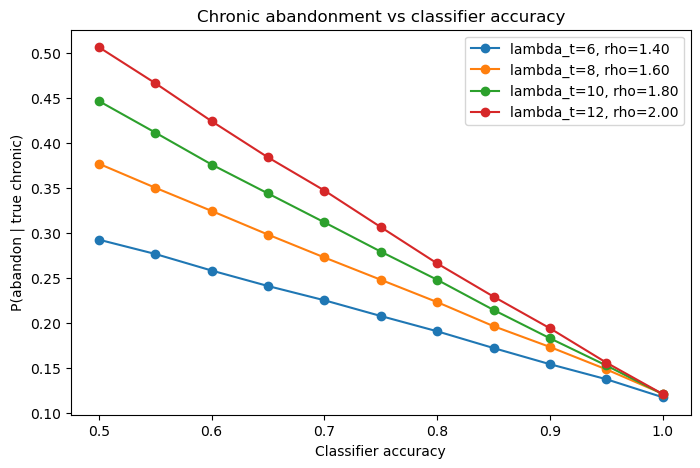

In [13]:
plt.figure(figsize=(8, 5))

for lambda_transient in lambda_transient_grid:
    g = plot_df[plot_df["lambda_transient"] == lambda_transient]
    rho = g["rho"].iloc[0]
    plt.plot(
        g["accuracy"],
        g["true_chronic_abandon_prob"],
        marker="o",
        label=f"lambda_t={lambda_transient:.0f}, rho={rho:.2f}"
    )

plt.xlabel("Classifier accuracy")
plt.ylabel("P(abandon | true chronic)")
plt.title("Chronic abandonment vs classifier accuracy")
plt.legend()
plt.show()

## Chronic abandonment vs classifier accuracy

We plot

$$
P(\text{abandon} \mid \text{true chronic})
$$

against classifier accuracy.

Each curve corresponds to a different overload level. This illustrates how better classification reduces abandonment among the intended priority population.

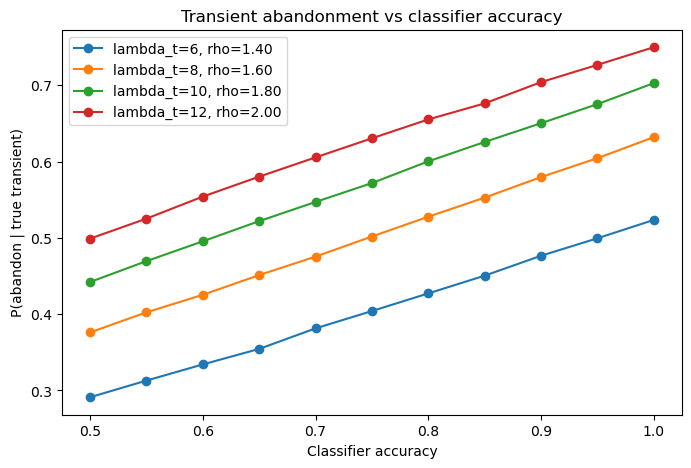

In [14]:
plt.figure(figsize=(8, 5))

for lambda_transient in lambda_transient_grid:
    g = plot_df[plot_df["lambda_transient"] == lambda_transient]
    rho = g["rho"].iloc[0]
    plt.plot(
        g["accuracy"],
        g["true_transient_abandon_prob"],
        marker="o",
        label=f"lambda_t={lambda_transient:.0f}, rho={rho:.2f}"
    )

plt.xlabel("Classifier accuracy")
plt.ylabel("P(abandon | true transient)")
plt.title("Transient abandonment vs classifier accuracy")
plt.legend()
plt.show()

## Simple analytic approximation for chronic abandonment

The simulation results show that the probability of abandonment among truly chronic individuals is approximately linear in classifier accuracy for each congestion level.

Let

$$
p_C(a;\rho) = P(\text{abandon} \mid \text{true chronic},\ \text{accuracy}=a,\ \rho)
$$

where

- $a$ is the classifier accuracy  
- $\rho$ is the system load

A simple approximation is obtained by interpolating between the uninformative classifier case $a=0.5$ and the perfect classifier case $a=1$:

$$
p_C(a;\rho)
\approx
p_C(0.5;\rho)
-
\frac{a-0.5}{0.5}
\Bigl(
p_C(0.5;\rho)-p_C(1;\rho)
\Bigr).
$$

Equivalently,

$$
p_C(a;\rho)
\approx
(2-2a)\,p_C(0.5;\rho)
+
(2a-1)\,p_C(1;\rho).
$$

This expression simply describes the straight line connecting the two extreme cases.

## Interpretation of the linear form

The linear relationship arises naturally from the classification mechanism.

For a truly chronic individual:

- with probability $a$ the classifier assigns them to the chronic priority class  
- with probability $1-a$ they are misclassified as transient.

If the queueing environment does not change dramatically with $a$, the abandonment probability is approximately a mixture of two cases:

$$
p_C(a;\rho)
\approx
a\,q_{C \to \hat C=0}(\rho)
+
(1-a)\,q_{C \to \hat C=1}(\rho),
$$

where

- $q_{C \to \hat C=0}$ is the abandonment probability when the individual is assigned to the chronic class  
- $q_{C \to \hat C=1}$ is the abandonment probability when misclassified.

Because this is a weighted mixture, the dependence on accuracy is approximately linear.

## Main finding

The probability that a truly chronic person abandons is strongly decreasing in classifier accuracy.

At the same time, heavier overload shifts the entire chronic-abandonment curve upward.

This means that better targeting is most valuable when the system is most congested.

## Interpretation

The mechanism is straightforward.

As classifier accuracy improves, more truly chronic customers are placed in the protected priority class. This lowers their abandonment probability.

The corresponding increase in transient abandonment shows that the policy is not creating capacity. It is reallocating scarce service toward the intended group.

## Overload interaction

The effect of classifier accuracy is substantially larger under heavier overload.

When congestion is modest, better classification still helps, but the gains are moderate.

When congestion is severe, better classification sharply reduces chronic abandonment, indicating that targeting quality becomes especially important when capacity is scarce.

## System-level perspective

Aggregate performance changes little with classifier accuracy:

- service rate stays close to total service capacity
- abandonment rate is mainly driven by overload
- queue length is mainly driven by overload

So classifier accuracy mostly affects **distributional outcomes across groups**, rather than total system throughput.

## Takeaway

This first homelessness study shows that imperfect prioritization can substantially increase chronic abandonment, especially in overloaded systems.

A more accurate classification tool protects the intended high-priority group, but does so by shifting abandonment toward the lower-priority group.

This is the basic tradeoff that the later policy experiments will refine.

.

.

.

.

## Benefit of classification accuracy

To highlight the value of improved classification, we compute the reduction in chronic abandonment relative to the uninformative classifier case

$$
a = 0.5
$$

The benefit is measured as

$$
\Delta(a) =
P(\text{abandon} \mid \text{true chronic}, a=0.5)
-
P(\text{abandon} \mid \text{true chronic}, a).
$$

This quantity represents how much chronic abandonment falls as classifier accuracy improves.

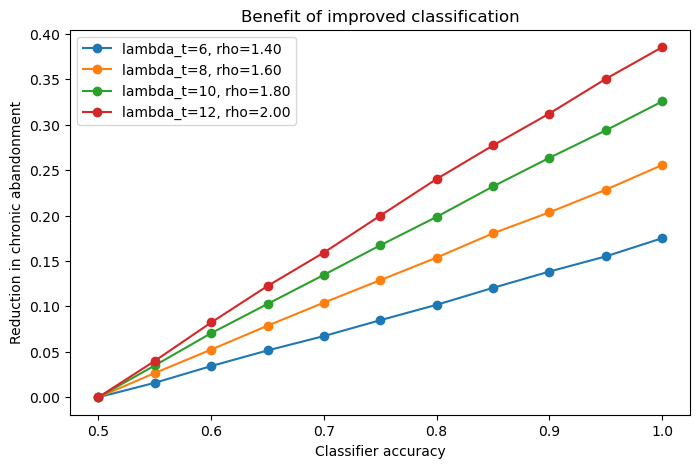

In [17]:
benefit_rows = []

for lambda_transient in lambda_transient_grid:

    g = plot_df[plot_df["lambda_transient"] == lambda_transient].copy()

    base = float(
        g.loc[g["accuracy"] == 0.5, "true_chronic_abandon_prob"].iloc[0]
    )

    for _, r in g.iterrows():
        benefit_rows.append({
            "lambda_transient": lambda_transient,
            "accuracy": r["accuracy"],
            "benefit": base - r["true_chronic_abandon_prob"],
            "rho": r["rho"],
        })

benefit_df = pd.DataFrame(benefit_rows)

plt.figure(figsize=(8,5))

for lambda_transient in lambda_transient_grid:

    g = benefit_df[benefit_df["lambda_transient"] == lambda_transient]
    rho = g["rho"].iloc[0]

    plt.plot(
        g["accuracy"],
        g["benefit"],
        marker="o",
        label=f"lambda_t={lambda_transient:.0f}, rho={rho:.2f}"
    )

plt.xlabel("Classifier accuracy")
plt.ylabel("Reduction in chronic abandonment")
plt.title("Benefit of improved classification")
plt.legend()
plt.show()

## Benefit of classification as congestion increases

We now reverse the perspective.

Instead of plotting chronic abandonment against classifier accuracy for each overload level, we fix several accuracy levels and study how the benefit of classification changes with congestion.

For a fixed accuracy $a$, define the benefit as

$$
\Delta(\rho, a)
=
P(\text{abandon} \mid \text{true chronic}, a=0.5, \rho)
-
P(\text{abandon} \mid \text{true chronic}, a, \rho).
$$

This measures how much chronic abandonment is reduced by using a classifier of accuracy $a$ rather than an uninformative classifier.

Plotting this against $\rho$ shows whether classification is more valuable in more overloaded systems.

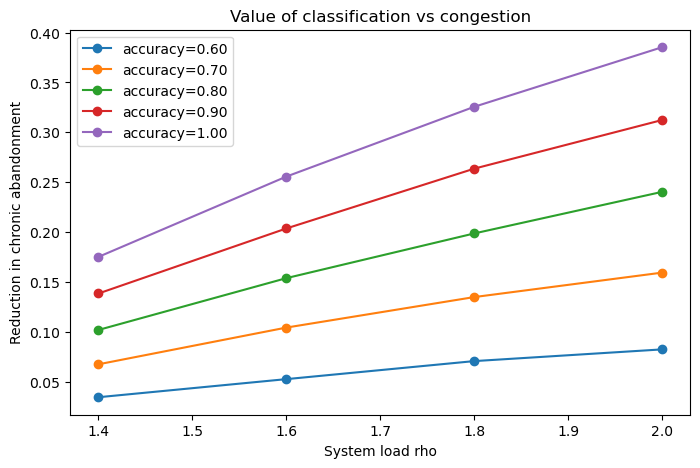

In [18]:
fixed_accuracy_levels = [0.6, 0.7, 0.8, 0.9, 1.0]

benefit_overload_rows = []

for lambda_transient in lambda_transient_grid:
    g = plot_df[plot_df["lambda_transient"] == lambda_transient].copy()

    base = float(
        g.loc[g["accuracy"] == 0.5, "true_chronic_abandon_prob"].iloc[0]
    )

    rho_val = float(g["rho"].iloc[0])

    for acc in fixed_accuracy_levels:
        val = float(
            g.loc[g["accuracy"] == acc, "true_chronic_abandon_prob"].iloc[0]
        )

        benefit_overload_rows.append({
            "lambda_transient": lambda_transient,
            "rho": rho_val,
            "accuracy": acc,
            "benefit": base - val,
        })

benefit_overload_df = pd.DataFrame(benefit_overload_rows)

plt.figure(figsize=(8, 5))

for acc in fixed_accuracy_levels:
    g = benefit_overload_df[benefit_overload_df["accuracy"] == acc].sort_values("rho")

    plt.plot(
        g["rho"],
        g["benefit"],
        marker="o",
        label=f"accuracy={acc:.2f}"
    )

plt.xlabel("System load rho")
plt.ylabel("Reduction in chronic abandonment")
plt.title("Value of classification vs congestion")
plt.legend()
plt.show()

## Chronic abandonment heatmap

To summarize the full experiment, we visualize chronic abandonment as a function of both:

- classifier accuracy
- system congestion

The heatmap displays

$$
P(\text{abandon} \mid \text{true chronic})
$$

over the grid of classifier accuracy and system load.

This provides a compact view of how classification quality and congestion jointly determine outcomes for the chronic population.

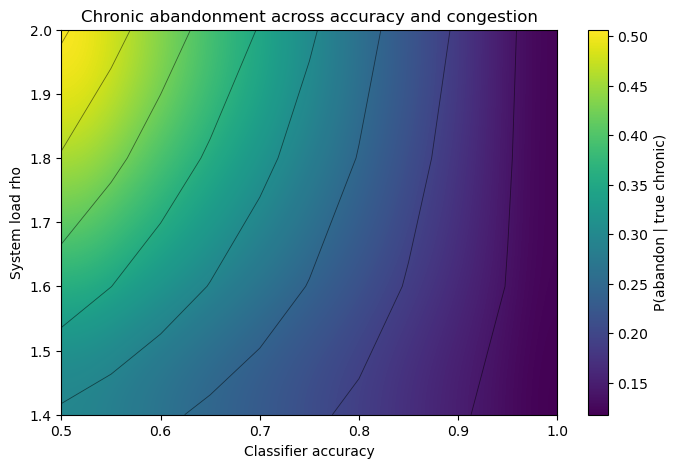

In [22]:
heatmap_df = plot_df[[
    "accuracy",
    "rho",
    "true_chronic_abandon_prob"
]]

pivot = heatmap_df.pivot(
    index="rho",
    columns="accuracy",
    values="true_chronic_abandon_prob"
)

x_vals = pivot.columns.values
y_vals = pivot.index.values
Z = pivot.values

plt.figure(figsize=(8,5))

im = plt.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    interpolation="bicubic"
)

plt.contour(
    x_vals,
    y_vals,
    Z,
    colors="black",
    linewidths=0.6,
    alpha=0.5
)

plt.colorbar(im, label="P(abandon | true chronic)")

plt.xlabel("Classifier accuracy")
plt.ylabel("System load rho")

plt.title("Chronic abandonment across accuracy and congestion")

plt.show()

## Interpretation

Two patterns are visible.

First, chronic abandonment decreases as classifier accuracy improves. Better targeting allows the system to prioritize the intended population more effectively.

Second, abandonment increases sharply with congestion. When the system is heavily overloaded, even accurate prioritization cannot fully prevent abandonment.

Together these results show that classification quality and system capacity interact strongly in determining outcomes for the chronic population.